In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

FOL917 - 4764385770.

* Abastecimiento de combustible, no concuerda con sensor del tanque de combustible, placa FOL917, abastecimiento 60 galones mas 61.55 galones, fecha 13-06-26

* Abastecimiento de 55.491 galones de petróleo, placa F0L917, fecha 14-06-26, no concuerda con el sensor de combustible.

Fuel tank 2 without information. It can cause missunderstandings.

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [29]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\t_pesqueros\Export_f0l917.xlsx') #excel
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3228 entries, 0 to 3227
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  3228 non-null   str  
 1   Message  3228 non-null   str  
 2   Status   3228 non-null   str  
dtypes: str(3)
memory usage: 75.8 KB


In [30]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [37]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')    
    if len(e0x_aux)>0:
        fs01=(e0x_aux[aux:aux+18])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])            
            msb=fs01[28:30]
            lsb=fs01[26:28]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0]) 
            msb=fs01[46:48]
            lsb=fs01[44:46]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            msb=fs01[46:48]
            lsb=fs01[44:46]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            msb=fs01[64:66]
            lsb=fs01[62:64]
            last_index_fs01=i        
            
#print(i, raw_fuel_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if len(e0x_aux)>0:
        fs02=e0x_aux[aux:aux+18]
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])            
            msb=fs02[28:30]
            lsb=fs02[26:28]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0]) 
            msb=fs02[46:48]
            lsb=fs02[44:46]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            msb=fs02[46:48]
            lsb=fs02[44:46]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            msb=fs02[64:66]
            lsb=fs02[62:64]
            last_index_fs02=i        
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
values_dates_fs01['Value fs01']=fs01_dec_value
values_dates_fs01['Dates fs01']=date_fs01_dec_value
values_dates_fs02['Value fs02']=fs02_dec_value
values_dates_fs02['Dates fs02']=date_fs02_dec_value

#print('El Ncode en decimal es:')
print(fs02_dec_value,fs02_count)
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])            


[21251, 21251, 21251, 21251] 4
Last fuel report fs01:  2026-06-19 17:51:10.798 Last fuel report fs02:  2026-06-18 00:00:32.217


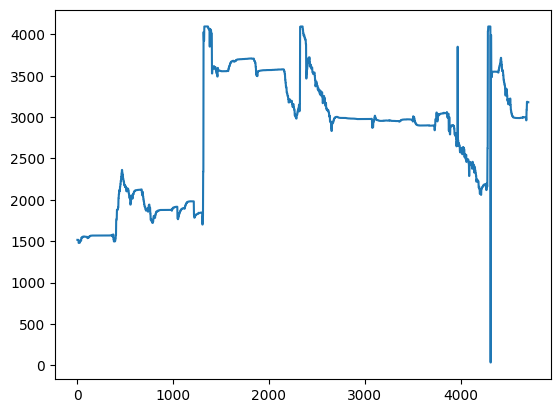

In [32]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)    

plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [33]:
int_value=int(input('Type the Ncode to look for: '))
for i in range(0,values_dates_fs01.shape[0]):
    if values_dates_fs01.iloc[i,0]>int_value:
        print(values_dates_fs01.loc[i])

Value fs01                       4028
Dates fs01    2026-06-13 18:56:08.393
Name: 1316, dtype: object
Value fs01                       4028
Dates fs01    2026-06-13 18:56:08.393
Name: 1317, dtype: object
Value fs01                       4028
Dates fs01    2026-06-13 18:56:08.393
Name: 1318, dtype: object
Value fs01                       4028
Dates fs01    2026-06-13 18:56:08.393
Name: 1319, dtype: object
Value fs01                       3925
Dates fs01    2026-06-13 19:02:08.419
Name: 1320, dtype: object
Value fs01                       3925
Dates fs01    2026-06-13 19:02:08.419
Name: 1321, dtype: object
Value fs01                       3925
Dates fs01    2026-06-13 19:02:08.419
Name: 1322, dtype: object
Value fs01                       3925
Dates fs01    2026-06-13 19:02:08.419
Name: 1323, dtype: object
Value fs01                       4095
Dates fs01    2026-06-13 19:07:50.204
Name: 1324, dtype: object
Value fs01                       4095
Dates fs01    2026-06-13 19:07:50.204
Name: 

In [34]:
for i in range(0,values_dates_fs02.shape[0]):
    if values_dates_fs01.iloc[i,0]>int_value:
        print(values_dates_fs01.loc[i])

Deep analysis.

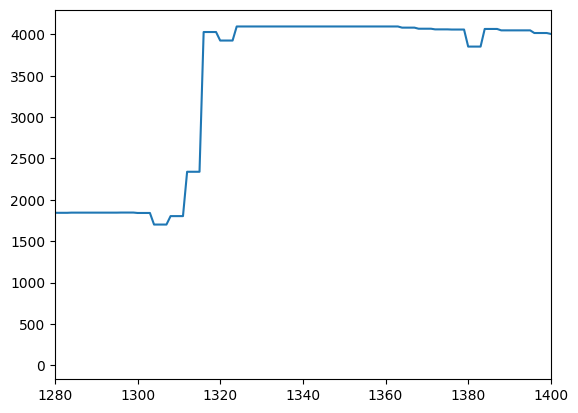

In [36]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

xi_axis=int(input("Type x_initial value: "))
xf_axis=int(input("Type x fina value: "))    

plt.xlim(xi_axis,xf_axis)
plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)